In [1]:
import subprocess, sys

paquetes = ["rasterio", "folium", "geopandas", "matplotlib", "numpy", "pillow"]

for pkg in paquetes:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True
    )

print("✅ Dependencias instaladas correctamente.")

✅ Dependencias instaladas correctamente.


In [2]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import rasterio
from rasterio.plot import show
from rasterio.warp import transform_bounds
from rasterio.crs import CRS
import geopandas as gpd
import folium
from folium import plugins
import io, base64, json
from PIL import Image

# ── Descarga del GeoTIFF RGB ───────────────────────────────────────────────
TIFF_URL = "https://raw.githubusercontent.com/rasterio/rasterio/main/tests/data/RGB.byte.tif"
TIFF_PATH = "satelital_RGB.tif"

if not os.path.exists(TIFF_PATH):
    print("⬇️  Descargando imagen satelital...")
    urllib.request.urlretrieve(TIFF_URL, TIFF_PATH)
    print("✅ Descarga completa.")
else:
    print("✅ Imagen ya disponible en disco.")

# ── Descarga del GeoJSON de países ────────────────────────────────────────
COUNTRIES_URL = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
COUNTRIES_PATH = "countries.geojson"

if not os.path.exists(COUNTRIES_PATH):
    print("⬇️  Descargando capa vectorial de países...")
    urllib.request.urlretrieve(COUNTRIES_URL, COUNTRIES_PATH)
    print("✅ Descarga completa.")
else:
    print("✅ GeoJSON ya disponible en disco.")

⬇️  Descargando imagen satelital...
✅ Descarga completa.
⬇️  Descargando capa vectorial de países...
✅ Descarga completa.


In [3]:
with rasterio.open(TIFF_PATH) as src:
    # ── Metadatos del archivo ──────────────────────────────────────────────
    print("=" * 55)
    print("       METADATOS DE LA IMAGEN SATELITAL")
    print("=" * 55)
    print(f"  Archivo          : {TIFF_PATH}")
    print(f"  Driver           : {src.driver}")
    print(f"  Número de bandas : {src.count}")
    print(f"  Ancho  (px)      : {src.width}")
    print(f"  Alto   (px)      : {src.height}")
    print(f"  Resolución       : {src.res[0]:.2f} m/px")
    print(f"  CRS original     : {src.crs}")
    print(f"  Extensión (m)    : {src.bounds}")

    # ── Transformar bounds a WGS84 (lat/lon) ──────────────────────────────
    wgs84 = CRS.from_epsg(4326)
    west, south, east, north = transform_bounds(
        src.crs, wgs84,
        src.bounds.left, src.bounds.bottom,
        src.bounds.right, src.bounds.top
    )
    print(f"  Extensión (lat/lon):")
    print(f"    Lon: {west:.4f}° → {east:.4f}°")
    print(f"    Lat: {south:.4f}° → {north:.4f}°")
    centro_lat = (north + south) / 2
    centro_lon = (east + west) / 2
    print(f"  Centro           : ({centro_lat:.4f}°, {centro_lon:.4f}°)")
    print("=" * 55)

    # ── Leer bandas ───────────────────────────────────────────────────────
    banda_r = src.read(1).astype(np.float32)   # Rojo
    banda_g = src.read(2).astype(np.float32)   # Verde
    banda_b = src.read(3).astype(np.float32)   # Azul

# ── Guardar para uso posterior ─────────────────────────────────────────────
BOUNDS_WGS84 = (west, south, east, north)
CENTRO = (centro_lat, centro_lon)

print("\n✅ Imagen leída correctamente. Bandas R, G, B disponibles.")

       METADATOS DE LA IMAGEN SATELITAL
  Archivo          : satelital_RGB.tif
  Driver           : GTiff
  Número de bandas : 3
  Ancho  (px)      : 791
  Alto   (px)      : 718
  Resolución       : 300.04 m/px
  CRS original     : EPSG:32618
  Extensión (m)    : BoundingBox(left=101985.0, bottom=2611485.0, right=339315.0, top=2826915.0)
  Extensión (lat/lon):
    Lon: -78.9586° → -76.5749°
    Lat: 23.5650° → 25.5509°
  Centro           : (24.5579°, -77.7668°)

✅ Imagen leída correctamente. Bandas R, G, B disponibles.


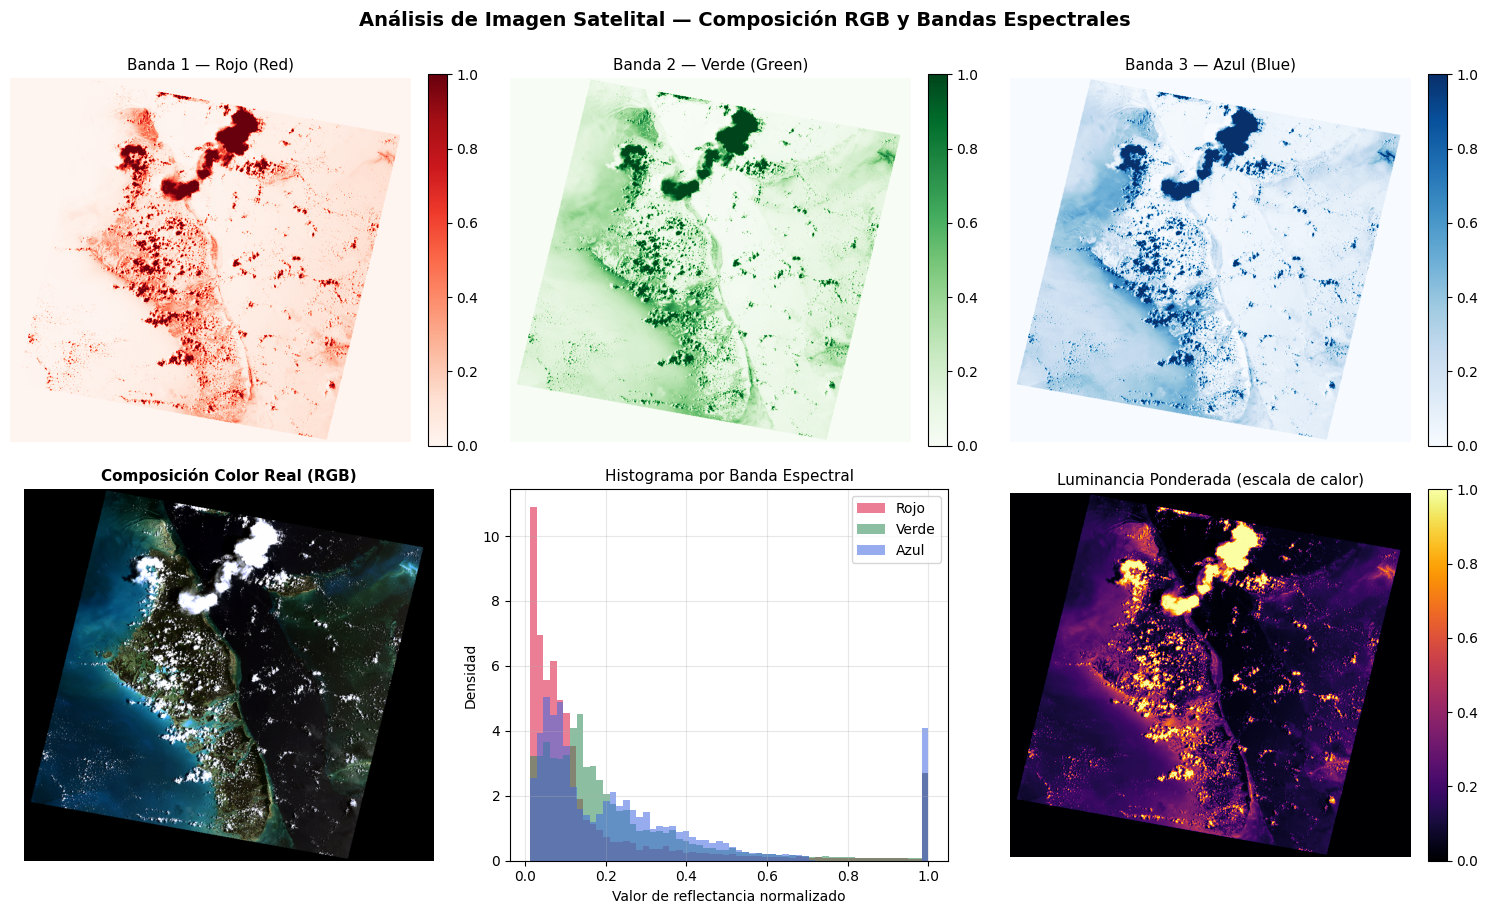

✅ Análisis visual completado. Figura guardada como 'analisis_satelital.png'.


In [4]:
def normalizar_banda(banda):
    """Estiramiento de contraste por percentiles 2-98 (técnica estándar en teledetección)."""
    mascara = banda > 0
    if mascara.sum() == 0:
        return np.zeros_like(banda)
    p2, p98 = np.percentile(banda[mascara], [2, 98])
    return np.clip((banda - p2) / (p98 - p2 + 1e-9), 0, 1)

# Normalizar cada banda
r_norm = normalizar_banda(banda_r)
g_norm = normalizar_banda(banda_g)
b_norm = normalizar_banda(banda_b)
imagen_rgb = np.dstack([r_norm, g_norm, b_norm])

# ── Figura principal ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Análisis de Imagen Satelital — Composición RGB y Bandas Espectrales",
             fontsize=14, fontweight="bold", y=1.01)

colores_bandas = ["Reds", "Greens", "Blues"]
nombres_bandas = ["Banda 1 — Rojo (Red)", "Banda 2 — Verde (Green)", "Banda 3 — Azul (Blue)"]
bandas = [r_norm, g_norm, b_norm]

# Fila 1: visualización de cada banda individual
for i, (ax, banda, cmap, nombre) in enumerate(zip(axes[0], bandas, colores_bandas, nombres_bandas)):
    im = ax.imshow(banda, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(nombre, fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Fila 2-izquierda: composición RGB
axes[1, 0].imshow(imagen_rgb)
axes[1, 0].set_title("Composición Color Real (RGB)", fontsize=11, fontweight="bold")
axes[1, 0].axis("off")

# Fila 2-centro: histograma de bandas
ax_hist = axes[1, 1]
for banda_data, color, label in zip(
    [r_norm, g_norm, b_norm],
    ["crimson", "seagreen", "royalblue"],
    ["Rojo", "Verde", "Azul"]
):
    vals = banda_data[banda_data > 0.01].flatten()
    ax_hist.hist(vals, bins=60, color=color, alpha=0.55, label=label, density=True)
ax_hist.set_title("Histograma por Banda Espectral", fontsize=11)
ax_hist.set_xlabel("Valor de reflectancia normalizado")
ax_hist.set_ylabel("Densidad")
ax_hist.legend()
ax_hist.grid(alpha=0.3)

# Fila 2-derecha: mapa de calor de luminancia
luminancia = 0.299 * r_norm + 0.587 * g_norm + 0.114 * b_norm
im3 = axes[1, 2].imshow(luminancia, cmap="inferno")
axes[1, 2].set_title("Luminancia Ponderada (escala de calor)", fontsize=11)
axes[1, 2].axis("off")
plt.colorbar(im3, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("analisis_satelital.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Análisis visual completado. Figura guardada como 'analisis_satelital.png'.")

In [5]:
np.random.seed(2024)
FILAS, COLS = 300, 300

# ── Simulación realista de reflectancias Landsat 8 ─────────────────────────
# Fondo base: suelo moderado
banda_RED = np.random.uniform(0.08, 0.15, (FILAS, COLS)).astype(np.float32)
banda_NIR = np.random.uniform(0.20, 0.30, (FILAS, COLS)).astype(np.float32)

# Zona 1: Selva amazónica (cuadrante inferior-izquierdo)
banda_RED[180:, :130]  = np.random.uniform(0.02, 0.06, (120, 130))
banda_NIR[180:, :130]  = np.random.uniform(0.45, 0.60, (120, 130))

# Zona 2: Andes — vegetación moderada (banda diagonal)
for i in range(50, 250):
    j0 = max(0, int(100 + (i - 50) * 0.5) - 20)
    j1 = min(COLS, j0 + 45)
    banda_RED[i, j0:j1] = np.random.uniform(0.05, 0.10, j1 - j0)
    banda_NIR[i, j0:j1] = np.random.uniform(0.30, 0.50, j1 - j0)

# Zona 3: Área urbana — Bogotá (centro)
banda_RED[120:170, 140:200] = np.random.uniform(0.18, 0.30, (50, 60))
banda_NIR[120:170, 140:200] = np.random.uniform(0.12, 0.22, (50, 60))

# Zona 4: Ríos y cuerpos de agua
banda_RED[70:90,  50:180]  = np.random.uniform(0.02, 0.06, (20, 130))
banda_NIR[70:90,  50:180]  = np.random.uniform(0.01, 0.04, (20, 130))
banda_RED[200:220, 160:300] = np.random.uniform(0.02, 0.05, (20, 140))
banda_NIR[200:220, 160:300] = np.random.uniform(0.01, 0.03, (20, 140))

# Zona 5: Páramo / pastizales de montaña (esquina superior derecha)
banda_RED[:80, 220:]  = np.random.uniform(0.07, 0.12, (80, 80))
banda_NIR[:80, 220:]  = np.random.uniform(0.20, 0.35, (80, 80))

# ── Cálculo del NDVI ───────────────────────────────────────────────────────
with np.errstate(divide='ignore', invalid='ignore'):
    ndvi = np.where(
        (banda_NIR + banda_RED) > 0,
        (banda_NIR - banda_RED) / (banda_NIR + banda_RED),
        np.nan
    )

# ── Estadísticas descriptivas ──────────────────────────────────────────────
ndvi_validos = ndvi[~np.isnan(ndvi)]
print("=" * 45)
print("   ESTADÍSTICAS NDVI")
print("=" * 45)
print(f"  Mínimo  : {ndvi_validos.min():.4f}")
print(f"  Máximo  : {ndvi_validos.max():.4f}")
print(f"  Media   : {ndvi_validos.mean():.4f}")
print(f"  Mediana : {np.median(ndvi_validos):.4f}")
print(f"  Std Dev : {ndvi_validos.std():.4f}")

# Clasificación por cobertura
categorias = {
    "Agua / Nieve"      : (ndvi < -0.1).sum(),
    "Suelo / Urbano"    : ((ndvi >= -0.1) & (ndvi < 0.1)).sum(),
    "Pastos / Páramo"   : ((ndvi >= 0.1)  & (ndvi < 0.3)).sum(),
    "Vegetación Moderada": ((ndvi >= 0.3) & (ndvi < 0.6)).sum(),
    "Bosque / Selva"    : (ndvi >= 0.6).sum(),
}
total = FILAS * COLS
print("\n  Distribución por cobertura:")
for cat, cant in categorias.items():
    print(f"    {cat:<22}: {cant:>6} px ({cant/total*100:5.1f}%)")
print("=" * 45)

   ESTADÍSTICAS NDVI
  Mínimo  : -0.7011
  Máximo  : 0.9350
  Media   : 0.4270
  Mediana : 0.4114
  Std Dev : 0.2945

  Distribución por cobertura:
    Agua / Nieve          :   6304 px (  7.0%)
    Suelo / Urbano        :   1822 px (  2.0%)
    Pastos / Páramo       :  13060 px ( 14.5%)
    Vegetación Moderada   :  47773 px ( 53.1%)
    Bosque / Selva        :  21041 px ( 23.4%)
